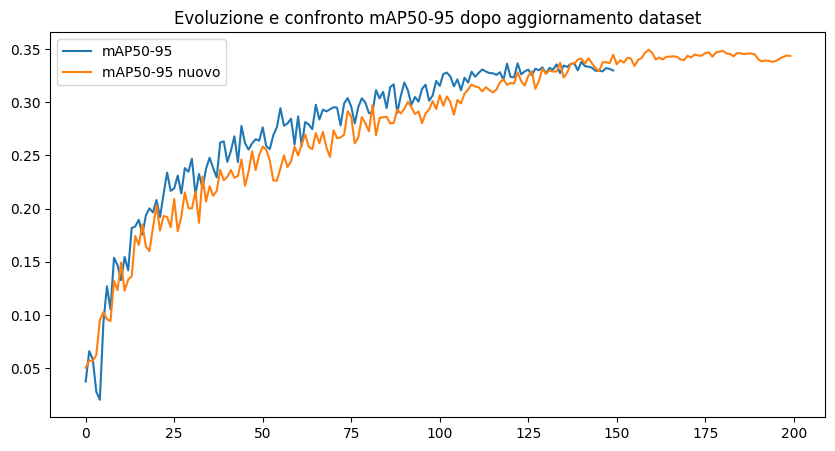

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt

resultsLargeOld = pd.read_csv('versioniPrecedenti/runs/segment26/large/modello26_large_150_64/results.csv')
resultsLargeOld.columns = resultsLargeOld.columns.str.strip()

resultsLargeNew = pd.read_csv('runs/segment/large26_200_32/results.csv')
resultsLargeNew.columns = resultsLargeNew.columns.str.strip()

plt.figure(figsize=(10,5))
plt.plot(resultsLargeOld['metrics/mAP50-95(M)'], label='mAP50-95')

plt.plot(resultsLargeNew['metrics/mAP50-95(M)'], label='mAP50-95 nuovo', )
plt.legend()

plt.title('Evoluzione e confronto mAP50-95 dopo aggiornamento dataset')
plt.show()

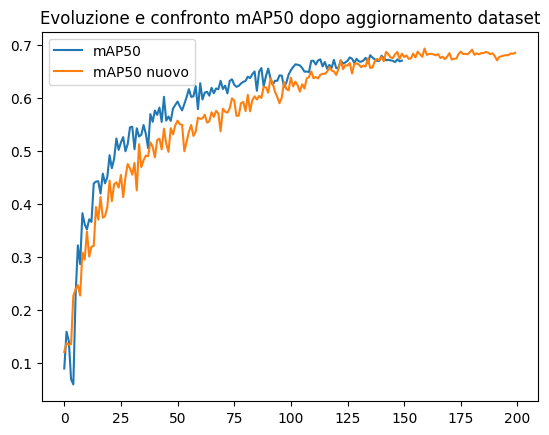

In [4]:
plt.plot(resultsLargeOld['metrics/mAP50(M)'], label='mAP50')

plt.plot(resultsLargeNew['metrics/mAP50(M)'], label='mAP50 nuovo', )
plt.legend()

plt.title('Evoluzione e confronto mAP50 dopo aggiornamento dataset')
plt.show()

C'è un problema di over saturation con l'extraLarge, 

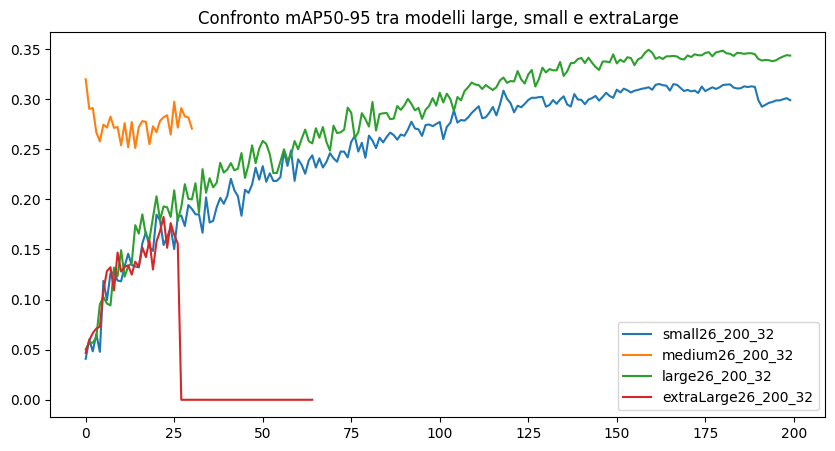

In [5]:
small = pd.read_csv('runs/segment/small26_200_32/results.csv')
medium = pd.read_csv('runs/segment/medium26_200_32/results.csv')
large = pd.read_csv('runs/segment/large26_200_32/results.csv')
extralarge = pd.read_csv('runs/segment/extraLarge26_200_32/results.csv')

plt.figure(figsize=(10,5))
plt.plot(small['metrics/mAP50-95(M)'], label='small26_200_32')
plt.plot(medium['metrics/mAP50-95(M)'], label='medium26_200_32')
plt.plot(large['metrics/mAP50-95(M)'], label='large26_200_32')
plt.plot(extralarge['metrics/mAP50-95(M)'], label='extraLarge26_200_32')

plt.legend()
plt.title('Confronto mAP50-95 tra modelli large, small e extraLarge')
plt.show()

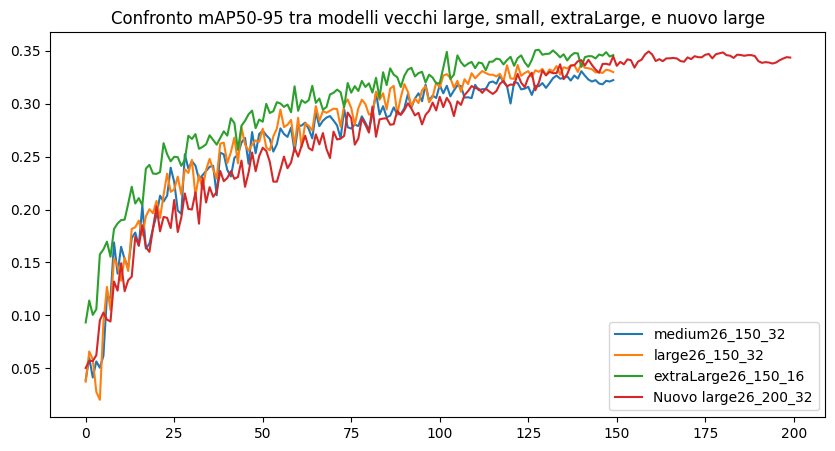

In [15]:
mediumOld = pd.read_csv('versioniPrecedenti/runs/segment26/medium/modello26_medium_150_64/results.csv')
largeOld = pd.read_csv('versioniPrecedenti/runs/segment26/large/modello26_large_150_64/results.csv')
xlOld = pd.read_csv('versioniPrecedenti/runs/segment26/extraLarge/modello26_extraLarge_150/results.csv')

plt.figure(figsize=(10,5))
plt.plot(mediumOld['metrics/mAP50-95(M)'], label='medium26_150_32')
plt.plot(largeOld['metrics/mAP50-95(M)'], label='large26_150_32')
plt.plot(xlOld['metrics/mAP50-95(M)'], label='extraLarge26_150_16')
plt.plot(large['metrics/mAP50-95(M)'], label='Nuovo large26_200_32')

plt.legend()
plt.title('Confronto mAP50-95 tra modelli vecchi large, small, extraLarge, e nuovo large')
plt.show()

In [25]:
def print_max_metrics(df, name, col='metrics/mAP50-95(M)'):
    """Stampa l'epoca e il valore massimo della metrica scelta."""
    aliases = {
        'mAP50-95': 'metrics/mAP50-95(M)',
        'mAP50-95(M)': 'metrics/mAP50-95(M)',
        'mAP50': 'metrics/mAP50(M)',
        'mAP50(M)': 'metrics/mAP50(M)',
        'precision(M)': 'metrics/precision(M)',
        'recall(M)': 'metrics/recall(M)',
        'mAP50(B)': 'metrics/mAP50(B)',
        'mAP50-95(B)': 'metrics/mAP50-95(B)',
        'precision(B)': 'metrics/precision(B)',
        'recall(B)': 'metrics/recall(B)'
    }
    if col not in df.columns and col in aliases:
        col = aliases[col]
    if col in df.columns:
        idx = df[col].idxmax()
        val = df[col].max()
        epoch = int(df.loc[idx, 'epoch']) if 'epoch' in df.columns else idx
        print(f"{name}: best epoch {epoch}, {col} = {val:.5f}")
    else:
        available = ', '.join(list(df.columns)[:40])
        print(f"{name}: column {col} not found. Available columns (sample): {available}")

print_max_metrics(small, 'small26_200_32', 'metrics/mAP50(M)')
print_max_metrics(large, 'large26_200_32', 'metrics/mAP50(M)')

print_max_metrics(mediumOld, 'medium26_150_64', 'metrics/mAP50(M)')
print_max_metrics(largeOld, 'large26_150_64', 'metrics/mAP50(M)')
print_max_metrics(xlOld, 'extraLarge26_150_32', 'metrics/mAP50(M)')


small26_200_32: best epoch 181, metrics/mAP50(M) = 0.65023
large26_200_32: best epoch 160, metrics/mAP50(M) = 0.69298
medium26_150_64: best epoch 122, metrics/mAP50(M) = 0.66283
large26_150_64: best epoch 136, metrics/mAP50(M) = 0.68025
extraLarge26_150_32: best epoch 103, metrics/mAP50(M) = 0.69816
